In [1]:
# 2365 lines, 32 solved, 9 passed_some_traininputs
# some cases are missed because of issues related to independent tokenization and 
# incomplete objective processing. We can't instill heuristics at the level of easy cases
# like that. We'd better fix what we can fix and wait for the system level of abstraction to pick up

# Other than this, this looks alright as a starter. The system needs to be tightened up
# by getting more dimesniosn and prior knowledge

# Overall, there are two obvious ways to go and both are necessary:
# 1) More abstraction at the scenario and global objective processing
# level, there are many variants that haven't been tackled yet
# 2) more prior knowledge, prior knowledge from objects and more
# from other neighbor spaces, we can really play this very well
# we have experience in mergers and we can set up more tasks this way.

from inductive_core_knowledge import * 

In [2]:
def print_arrays(case_num):
    this_task = TaskManager(tt[case_num])
    this_task.brief_task()
    return this_task

In [3]:
from pathlib import Path
data_path = Path("/home/hshallal/Desktop/ARCsolver/data/")
training_path = data_path / 'training'
tt = load_set(training_path)

1
[<function apply_scenarios at 0x7f263b238310>]


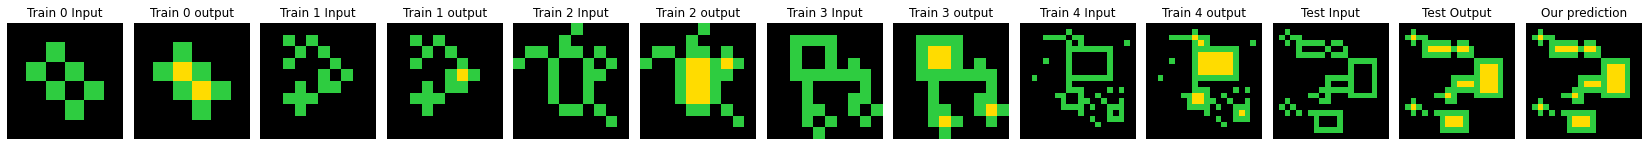

====
15
[<function apply_value_maps at 0x7f263b238280>]


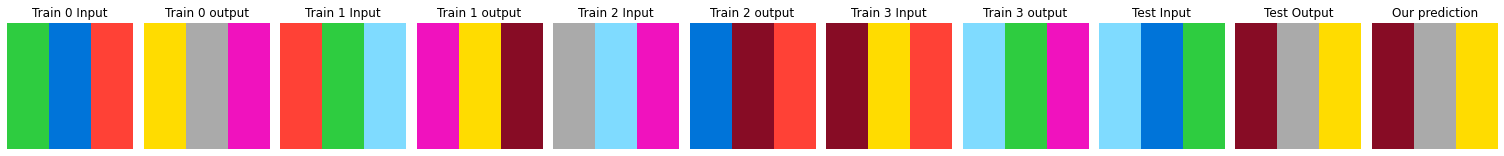

====


/home/hshallal/Desktop/ARCsolver/utils.py:493: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  target_indices = (np.argwhere(in_ == x[0]), np.argwhere(out_ == x[1]))


54
[<function apply_scenarios at 0x7f263b238310>]


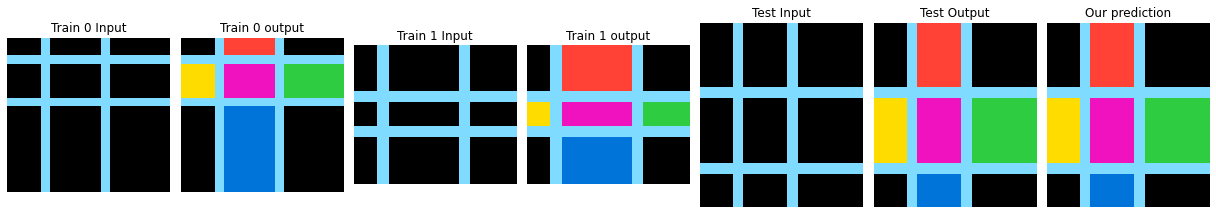

====
72
[<function apply_scenarios at 0x7f263b238310>]


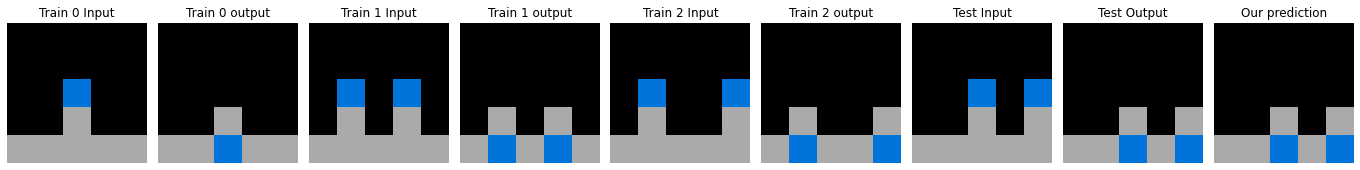

====
86
[<function screen_flips_rotation at 0x7f263b2aea60>]


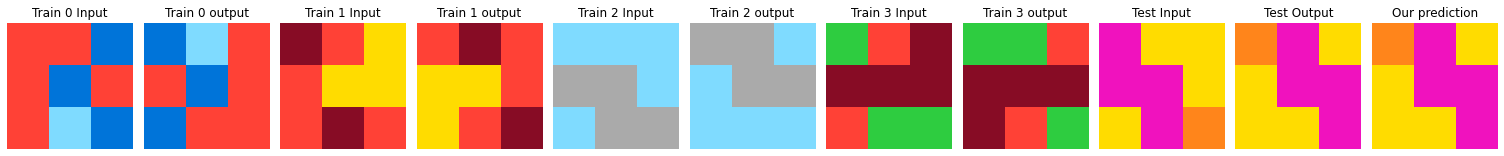

====
94
[<function apply_scenarios at 0x7f263b238310>]


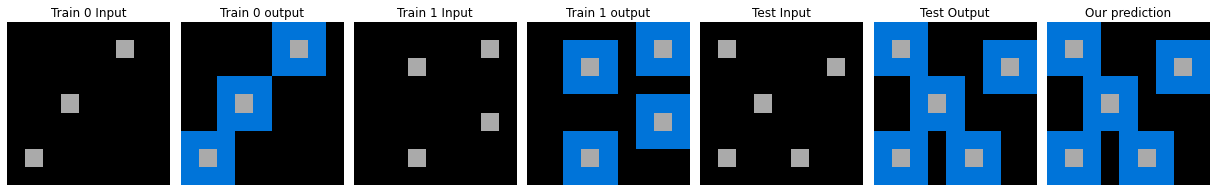

====
96
[<function apply_scenarios at 0x7f263b238310>]


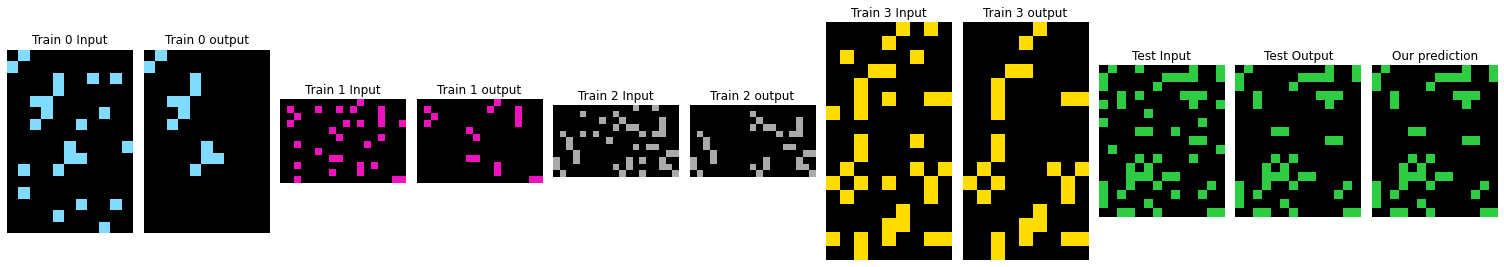

====
97
[<function apply_scenarios at 0x7f263b238310>]


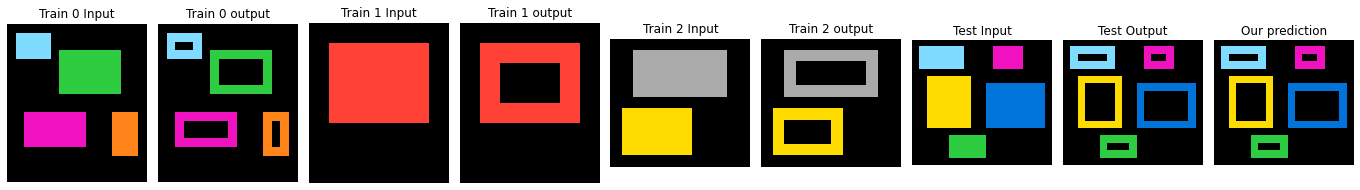

====
119
[<function apply_scenarios at 0x7f263b238310>]


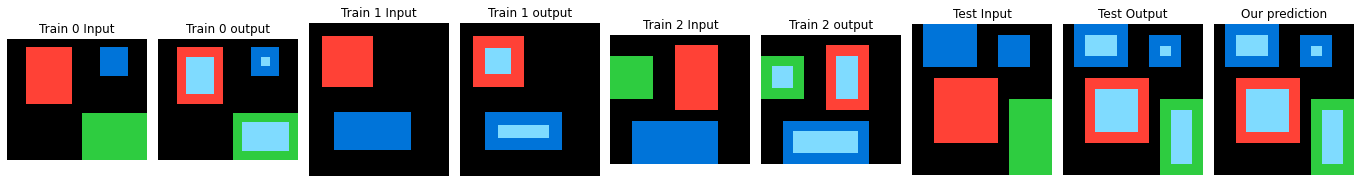

====
124
[<function apply_scenarios at 0x7f263b238310>]


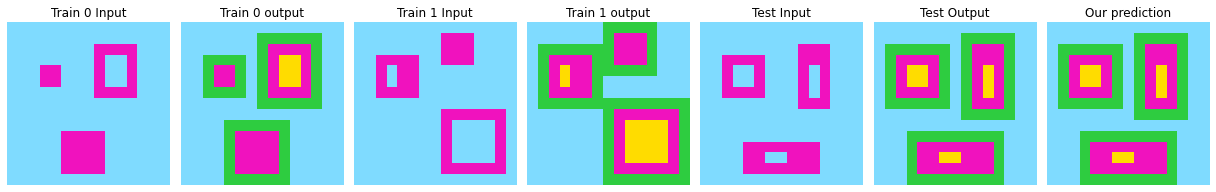

====
128
[<function apply_scenarios at 0x7f263b238310>]


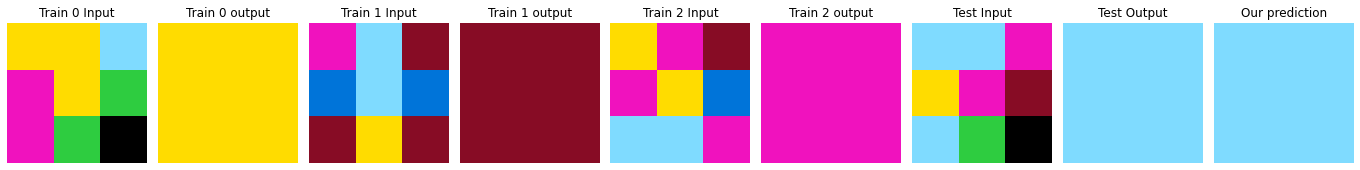

====
139
[<function screen_flips_rotation at 0x7f263b2aea60>]


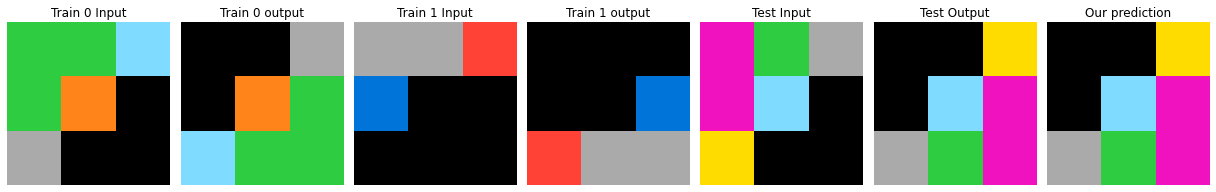

====
149
[<function screen_flips_rotation at 0x7f263b2aea60>]


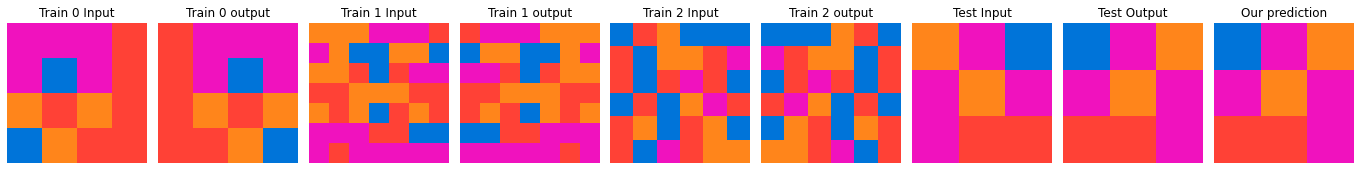

====
154
[<function screen_flips_rotation at 0x7f263b2aea60>]


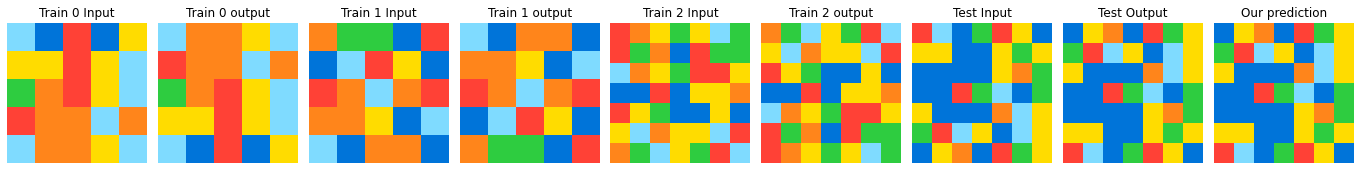

====
178
[<function screen_flips_rotation at 0x7f263b2aea60>]


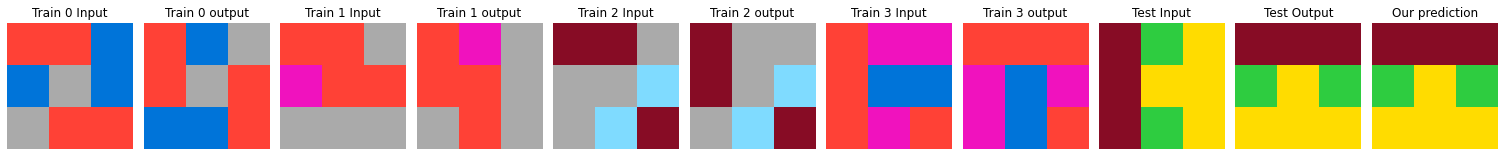

====
186
[<function apply_scenarios at 0x7f263b238310>]


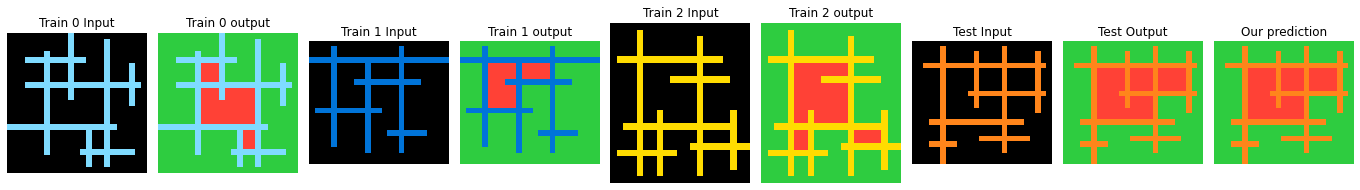

====
222
[['is_exp_cont', [3.0, 3.0]]]


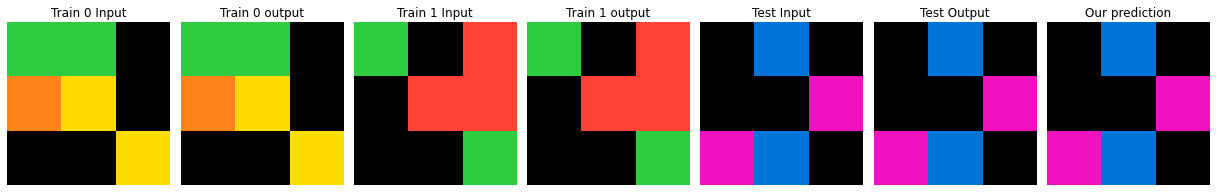

====
240
[<function screen_flips_rotation at 0x7f263b2aea60>]


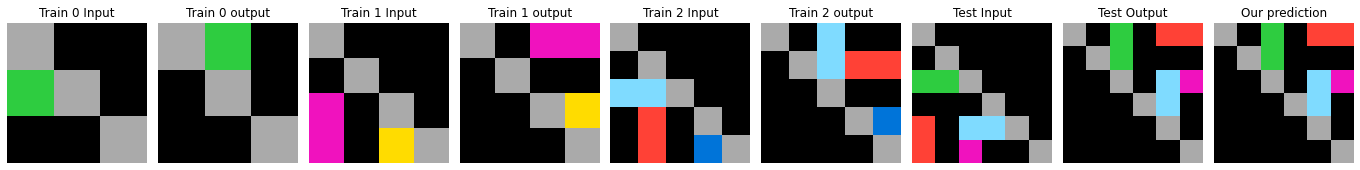

====
250
[<function apply_scenarios at 0x7f263b238310>]


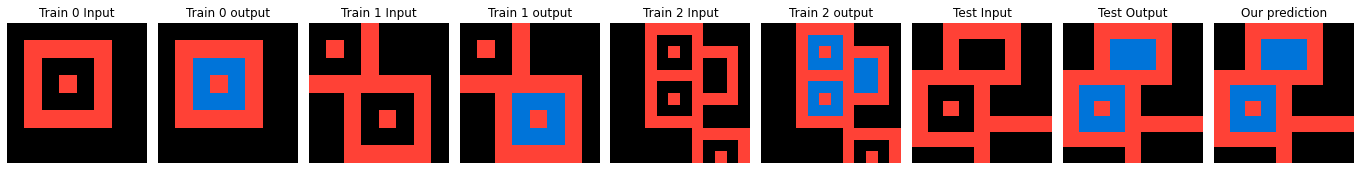

====
266
[<function apply_scenarios at 0x7f263b238310>]


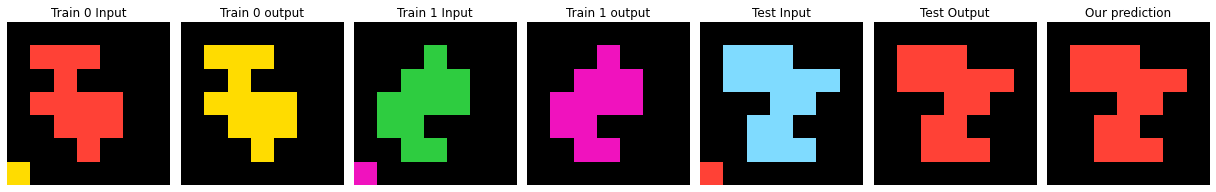

====
268
[['is_exp_cont_freq_unique_nonbg', [2.0, 3.0, 5.0]]]


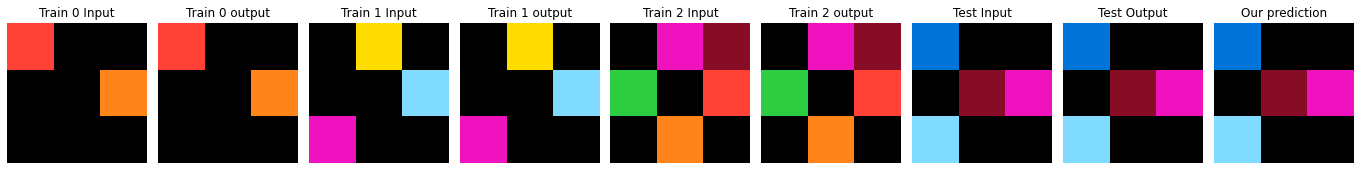

====
275
[<function apply_value_maps at 0x7f263b238280>]


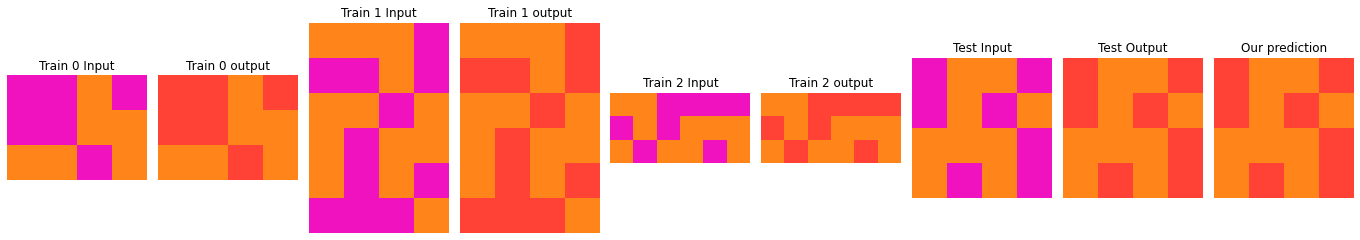

====
288
[['is_exp_cont_freq_unique_nonbg', [2.0, 2.0, 3.0, 3.0, 4.0]]]


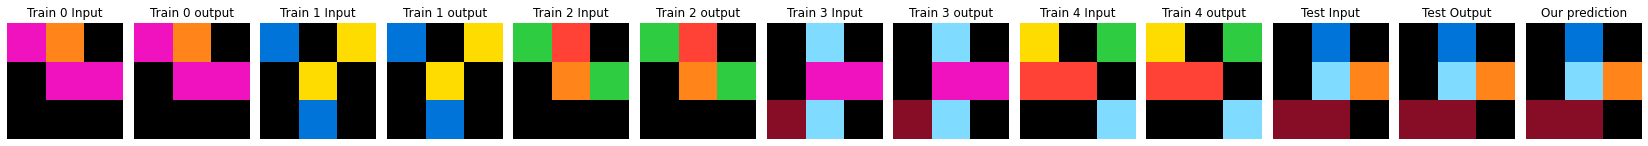

====
293
[<function apply_scenarios at 0x7f263b238310>]


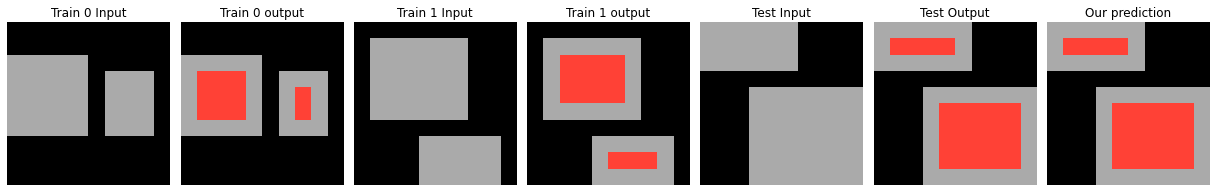

====
306
[['is_exp_cont', [2.0, 2.0]]]


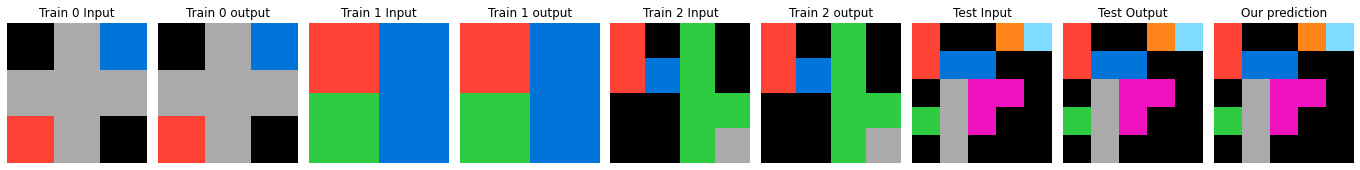

====
308
[<function apply_value_maps at 0x7f263b238280>]


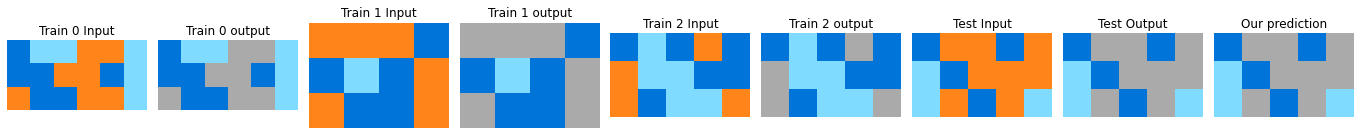

====
316
[<function apply_scenarios at 0x7f263b238310>]


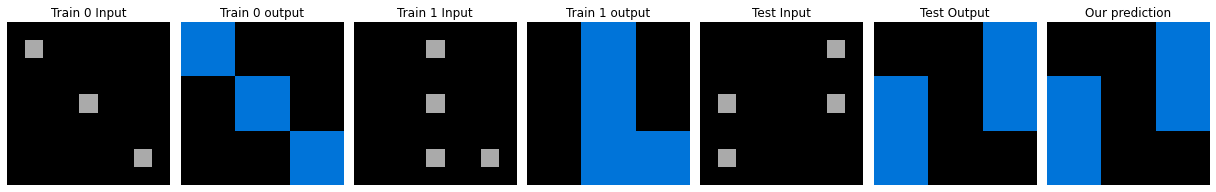

====
336
[<function apply_scenarios at 0x7f263b238310>]


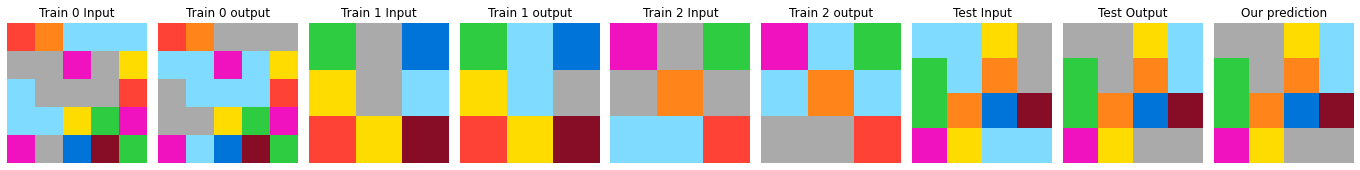

====
337
[<function apply_scenarios at 0x7f263b238310>]


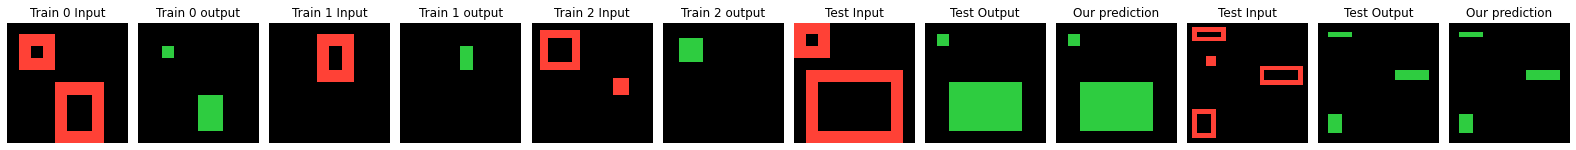

====
372
[<function apply_scenarios at 0x7f263b238310>]


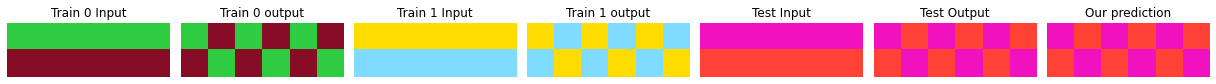

====
379
[<function screen_flips_rotation at 0x7f263b2aea60>]


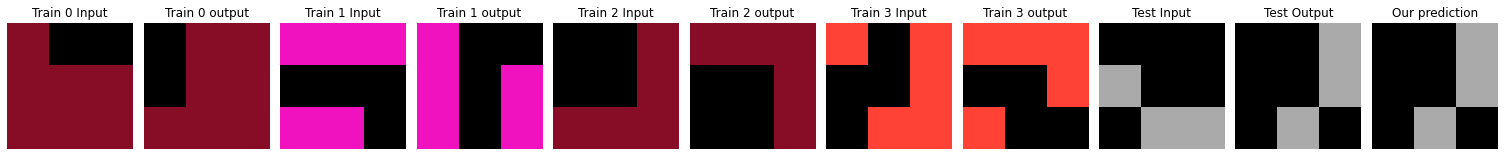

====
388
[<function apply_scenarios at 0x7f263b238310>]


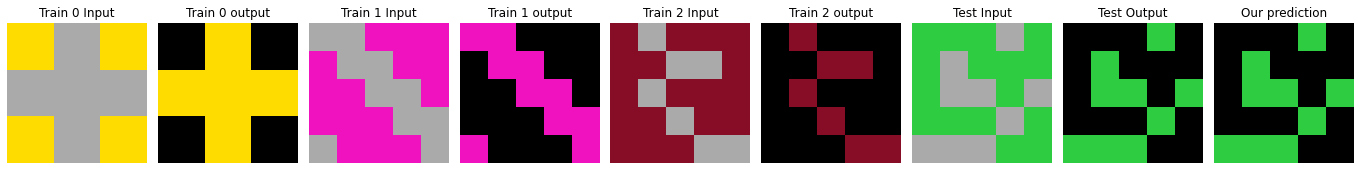

====
It took this number of seconds:  1709.7713695779967
400


In [4]:
from timeit import default_timer as timer
start = timer()
today_analysis = []
for n in range(len(tt)):
    this_task = Inductive(tt[n])
    today_analysis.append(this_task)
    if this_task.solved == 'solved':
        print(n)
        print(this_task.mechanisms)
        plot_task_eval(tt[n], [x.astype('int64') for x in this_task.test_situation])
        print('====')
    

serialize(today_analysis, 'assets/today_analysis')
end = timer()
print("It took this number of seconds: ", end - start)
print(len(today_analysis))
# It took this number of seconds: 1015

In [4]:
previous_analysis = load_serialized('assets/today_analysis')
#previous_screening_results = load_serialized('assets/screening_results')

In [6]:
# screen_dimensions tasks: 222, 268, 288, 306
# direct_transformatio: 266, 336, 388
# single output: 99, 128, 338

In [5]:
current_attention = []
for n in range(400):
    this_task = previous_analysis[n]
    if this_task.is_complete_objective and this_task.dimension_status == 'deduced' and this_task.solved != 'solved':
        current_attention.append(n)
        
print(len(current_attention))

51


In [8]:
coding_situation = {}
coding_situation[-1] = []
coding_situation[0] = []
coding_situation[1] = []


for n in range(len(previous_analysis)):
    this_task = previous_analysis[n]
    if this_task.objective_status == 'irr':
        coding_situation[-1].append(n)
    elif this_task.objective_status == 'obd':
        coding_situation[0].append(n)
    elif this_task.objective_status == 'red':
        coding_situation[1].append(n)

        
for k, v in coding_situation.items():
    print(k, ' : ', len(v))

results_dict = {}
results_dict['ineligible'] = []
results_dict['passed_all_traininputs'] = []
results_dict['passed_some_traininputs'] = []
results_dict['unpassed_all_traininputs'] = []
results_dict['passed_all_testinputs'] = []
results_dict['passed_some_testinputs'] = []
results_dict['unpassed_all_testinputs'] = []
results_dict['unknown'] = []

ranking_dict = {}
ranking_dict['ineligible'] = 0
ranking_dict['unpassed_all_traininputs'] = 1
ranking_dict['passed_some_traininputs'] = 2
ranking_dict['passed_all_traininputs'] = 3
ranking_dict['unpassed_all_testinputs'] = 4
ranking_dict['passed_some_testinputs'] = 5
ranking_dict['passed_all_testinputs'] = 6

rev_ranking_dict = {v:k for k, v in ranking_dict.items()}

def screen_all(previous_analysis):
    results = deepcopy(results_dict)
    
    for task in range(len(previous_analysis)):
        #print(task)
        this_task = deepcopy(previous_analysis[task])
        current_situation, train_situation, train_screen, test_situation, test_screen = this_task.current_situation, this_task.train_situation, this_task.train_screen, this_task.test_situation, this_task.test_screen
        
        if current_situation in results_dict.keys():
            results[current_situation].append(task)
        else:
            results['unknown'].append((task, current_situation))

    for k, v in results.items():
        print(k, ' : ', len(v))
    
    return results

screening_results = screen_all(previous_analysis)
# print(this_task.apply_routine_list)

serialize(screening_results, 'assets/screening_results')

all_undeduced = 0
for n in previous_analysis:
    if n.dimension_status != 'deduced':
        all_undeduced += 1
all_undeduced

# training: 310 deduces: 0.775
# -1  :  64 # irr
# 0  :  245 # obd
# 1  :  91 # red 


-1  :  64
0  :  245
1  :  91
ineligible  :  368
passed_all_traininputs  :  0
passed_some_traininputs  :  0
unpassed_all_traininputs  :  0
passed_all_testinputs  :  32
passed_some_testinputs  :  0
unpassed_all_testinputs  :  0
unknown  :  0


95

In [11]:
# print(this_task.apply_routine_list)
screening_results = {}
solved = 0
for n in range(400):
    this_task = previous_analysis[n]
    if this_task.solved == 'solved':
        solved += 1
    overall = [x[2] for x in this_task.apply_routine_list]
    imp = [x for x in overall if x != 'ineligible']
    for m in overall:
        if m != 'ineligible':
            if m not in screening_results.keys():
                screening_results[m] = []
            screening_results[m].append(n)

for k, v in screening_results.items():
    print(k, ' : ', len(v))
    
print(solved)

passed_all_testinputs  :  28
passed_some_traininputs  :  9
32


In [35]:
def demonstrate_heuristic_candidacy(this_task):
    print(n)
    plot_task(tt[n])
    print('Situation: ', [x[2] for x in this_task.apply_routine_list])
    print(this_task.objective_status, this_task.running_objective, this_task.global_objective)
    print(this_task.train_screen, this_task.test_screen)
    print(this_task.token_to_colors, this_task.test_token_to_colors, )
    print(this_task.pr_kn_apply_scenarios)
    print('=====')

99


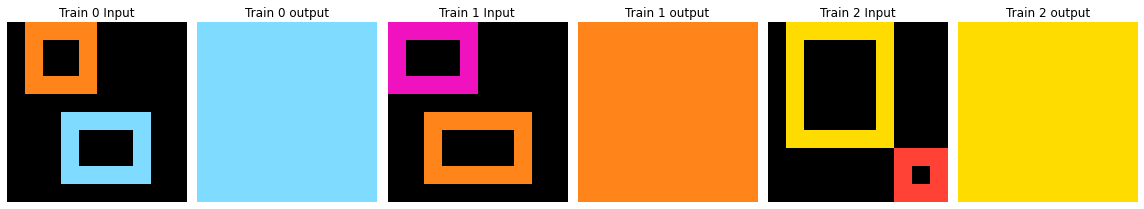

Situation:  ['ineligible', 'ineligible', 'ineligible']
obd [[[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct'), [1, 4], (1, {8, 4, 7}), (4, {1})]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct'), [1, 4], (1, {7}), (4, {1})]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct'), [1, 4, 5], (1, {4}), (4, {1}), (5, {2})]]] [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct'), [1, 4], (1, {8, 4, 7}), (4, {1})]]
[True, True, True] [False]
[{'bg': 0, 'nonbg0': 7, 'nonbg1': 8}, {'bg': 0, 'nonbg0': 6, 'nonbg1': 7}, {'bg': 0, 'nonbg0': 2, 'nonbg1': 4}] [{'bg': 0, 'nonbg0': 3, 'nonbg1': 9}]
[['nonbg1', 4, [1], 'nonbg1']]
=====
338


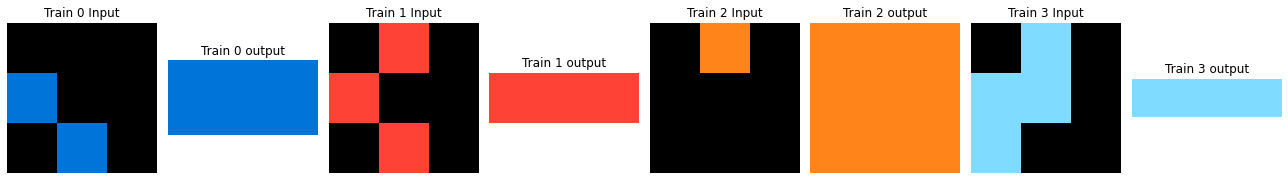

Situation:  ['ineligible', 'ineligible', 'ineligible']
obd [[[('bg', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4], (1, {8, 1, 2, 7}), (4, {0})]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {2}), (4, {0}), (5, {15})]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4], (1, {7}), (4, {0})]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {8}), (4, {0}), (5, {15})]]] [[('bg', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4], (1, {8, 1, 2, 7}), (4, {0})]]
[True, True, True, True] [False]
[{'bg': 0, 'nonbg0': 1}, {'bg': 0, 'nonbg0': 2}, {'bg': 0, 'nonbg0': 7}, {'bg': 0, 'nonbg0': 8}] [{'bg': 0, 'nonbg0': 4}]
[['nonbg0', 4, [0], 'nonbg0']]
=====
345


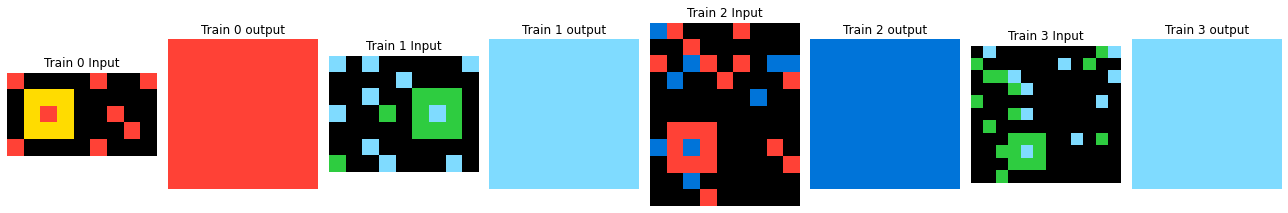

Situation:  ['ineligible', 'ineligible', 'ineligible']
irr [[[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1], (1, {8, 1, 2})]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct'), [1, 5], (1, {8}), (5, {0})]], [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {1}), (4, {0}), (5, {5})]], [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4], (1, {8}), (4, {0})]]] [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1], (1, {8, 1, 2})]]
[False, False, False, False] ['nil']
[{'bg': 0, 'nonbg0': 2, 'nonbg1': 4}, {'bg': 0, 'nonbg0': 3, 'nonbg1': 8}, {'bg': 0, 'nonbg0': 1, 'nonbg1': 2}, {'bg': 0, 'nonbg0': 8, 'nonbg1': 3}] [{'bg': 0, 'nonbg0': 4, 'nonbg1': 1}]
[['nonbg0', 1, [8, 1, 2], 'x', 'nonbg0']]
=====
343


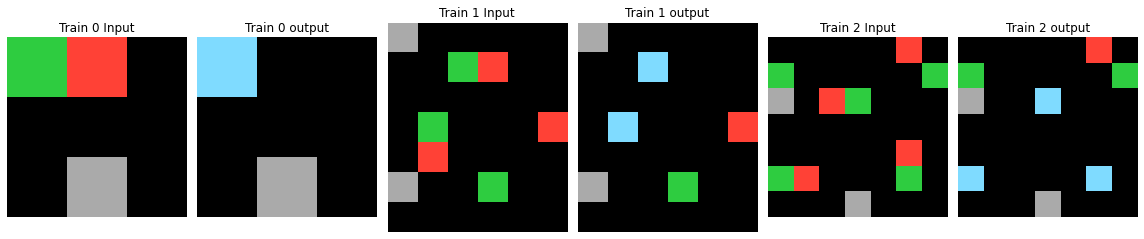

Situation:  ['passed_some_traininputs', 'ineligible', 'passed_some_traininputs']
red [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg2pr', 'direct')]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [2, 3, 6], (2, {3}, {1, 4}), (3, {5}, {1, 3}), (6, {1}, {2, 3})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [2, 3, 6], (2, {5}, {1, 3}), (3, {3}, {1, 2}), (6, {1}, {2})]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [2], (2, {0}, {2, 4, 5})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [2], (2, {1}, {2, 5})]]] [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg2pr', 'direct')]]
[True, False, False] ['nil']
[{'bg': 0, 'nonbg0pr': 2, 'nonbg1pr': 3, 'nonbg2pr': 8}, {'bg': 0, 'nonbg0pr': 2, 'nonbg1pr': 3, 'nonbg2pr': 8}, {'bg': 0, 'nonbg0pr': 2, 'nonbg1pr': 3, 'nonbg2pr': 8}] [{'bg': 0, 'nonbg0pr': 2, 'nonbg1pr': 3, 'nonbg2pr': 8}]
[['nonbg0pr', 'direct', 'bg'], ['nonbg1pr', 'direct', 'nonbg2pr']]
=====
228


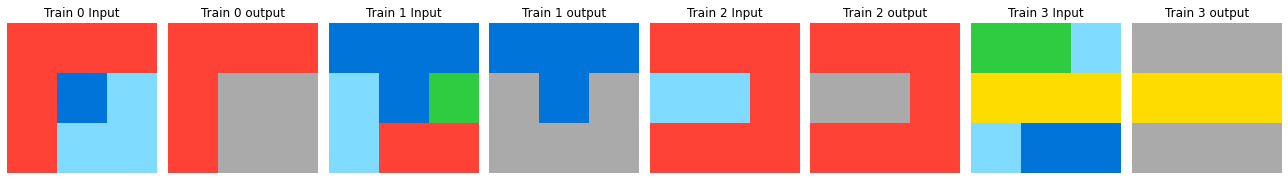

Situation:  ['passed_some_traininputs', 'ineligible', 'ineligible']
red [[[('nonbg0', 'nonbg-1pr', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')]], [[('nonbg0', 'nonbg-1pr', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')], [('nonbg2', 'nonbg-1pr', 'direct')]], [[('nonbg0', 'nonbg-1pr', 'direct')]], [[('nonbg0', 'nonbg-1pr', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')], [('nonbg2', 'nonbg-1pr', 'direct')]]] [[('nonbg0', 'nonbg-1pr', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')], [('nonbg2', 'nonbg-1pr', 'direct')]]
[True, True, True, True] [False]
[{'nonbg-1pr': 5, 'nonbg0': 1, 'nonbg1': 8}, {'nonbg-1pr': 5, 'nonbg0': 3, 'nonbg1': 2, 'nonbg2': 8}, {'nonbg-1pr': 5, 'nonbg0': 8}, {'nonbg-1pr': 5, 'nonbg0': 1, 'nonbg1': 3, 'nonbg2': 8}] [{'nonbg-1pr': 5, 'nonbg0': 1, 'nonbg1': 2, 'nonbg2': 3}]
[['nonbg0', 'direct', 'nonbg-1pr'], ['nonbg1', 'direct', 'nonbg-1pr'], ['nonbg2', 'direct', 'nonbg-1pr']]
=====
292


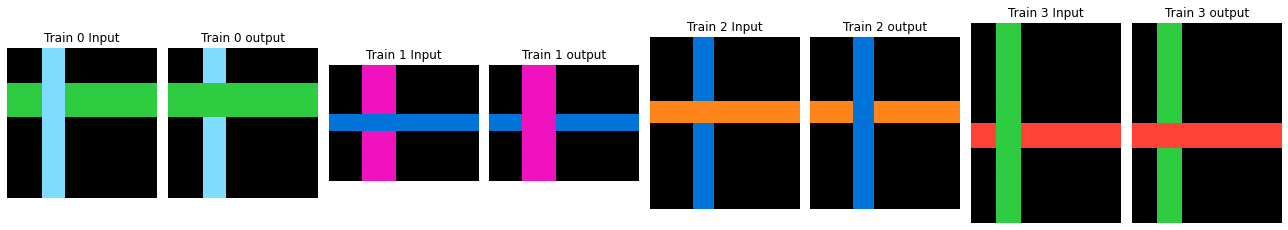

Situation:  ['ineligible', 'ineligible', 'passed_some_traininputs']
irr [[[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [5], (5, {5, 7, 8, 9, 12, 14}, {0})]], [[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [3, 5], (3, {0, 1, 4, 5, 6, 7, 8}, {2, 3}), (5, {12, 14}, {0})]], [[('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0'), [3, 5], (3, {0, 1, 3, 4, 5, 6}, {2}), (5, {12, 14}, {0})]], [[('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0'), [2, 5], (2, {0, 1, 2, 3, 5, 6, 7}, {4}), (5, {11, 13}, {0})]]] [[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [5], (5, {5, 7, 8, 9, 12, 14}, {0})]]
[True, True, False, False] ['nil']
[{'bg': 0, 'nonbg0': 8, 'nonbg1': 3}, {'bg': 0, 'nonbg0': 1, 'nonbg1': 6}, {'bg': 0, 'nonbg0': 1, 'nonbg1': 7}, {'bg': 0, 'nonbg0': 2, 'nonbg1': 3}] [{'bg': 0, 'nonbg0': 5, 'nonbg1': 4}]
[['nonbg1', 'direct', 'nonbg1'], ['nonb

In [37]:
# all unique output
# 99: has a tie between two values in test that caused it to miss on the test: [{'bg': 0, 'nonbg0': 3, 'nonbg1': 9}]
# 338: there is an implied rule of no bg output leaving only one option, this rule is in the objective, was ommitted and the prior knowledge routine picks the bg rather than the nonbg
# 345: matther of better prior knowledge: picked up on a value based in the scenarios, hmm,
# this makes the case for legitimate free plays stronger given that a value based based
# choice is by no means deterministic given the independent tokenization of train and test
# inputs
# case 343: the global objective didn't pick up on the other more elaborate objectives
# [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg2pr', 'direct')]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [2, 3, 6], (2, {3}, {1, 4}), (3, {5}, {1, 3}), (6, {1}, {2, 3})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [2, 3, 6], (2, {5}, {1, 3}), (3, {3}, {1, 2}), (6, {1}, {2})]]
# case 228: tokenization of test didn't spare an int anchor which is be default
# is the one spared of tokenization, in the test case, this did't happen,
# this is a tokenization issue. In addition, the solution is already in the prior knowledge
# it is just that the system blindly tokenized the whole test without sparing the most
# frequent indicated by 2 in the sorted frequency graph!
# case 292 is an objective issue due to the independent tokenization, global objective must
# have collected other issues
# check_heuristics: is_single_output, pass_info: is bg in outputs, bg
#                   99: output two same frequency nonbg
#                   338: exclude bg
# apply_heuristcs: 1) check multiple nonbg if you have <= three options along with the passed_info
#                  2) include other heuristics
heuristic_cases = [99, 338, 345, 343, 228, 292]
for n in heuristic_cases:
    demonstrate_heuristic_candidacy(Inductive(tt[n]))

51


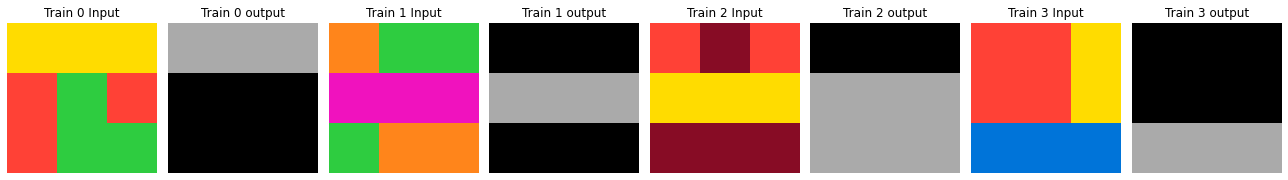

142


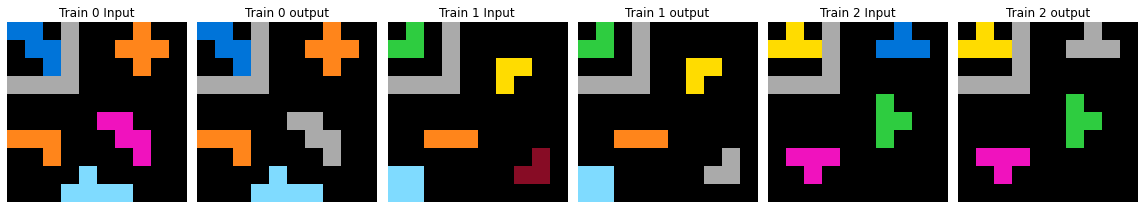

202


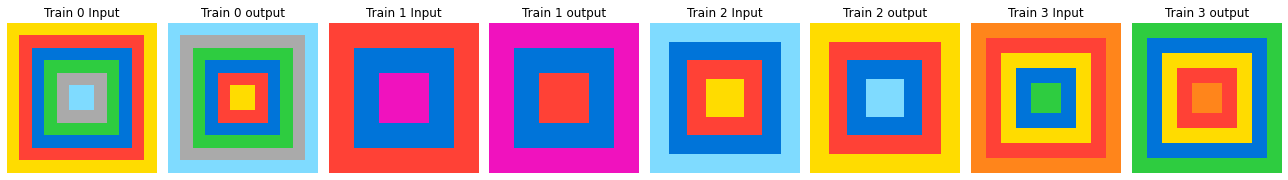

228


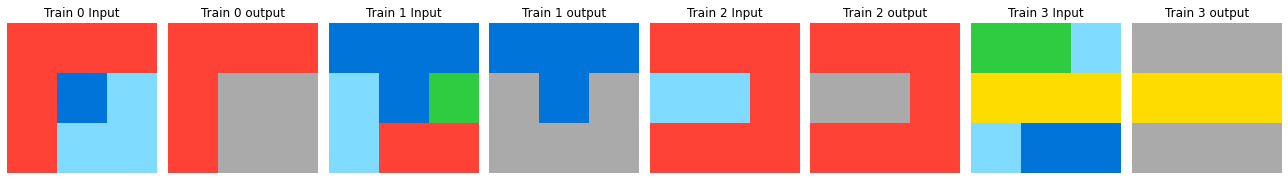

292


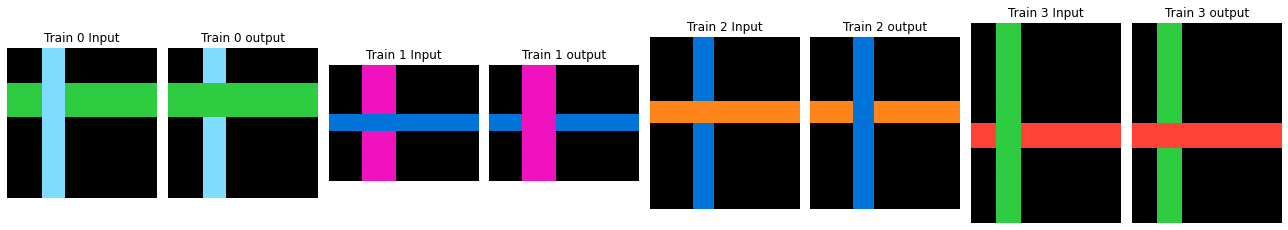

297


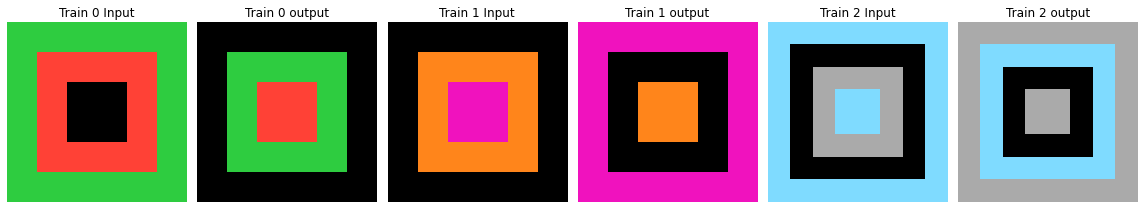

328


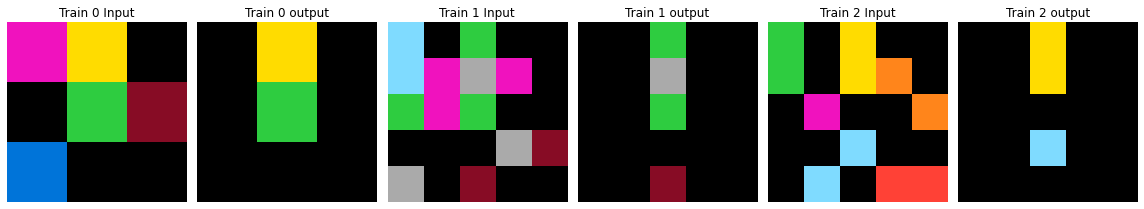

343


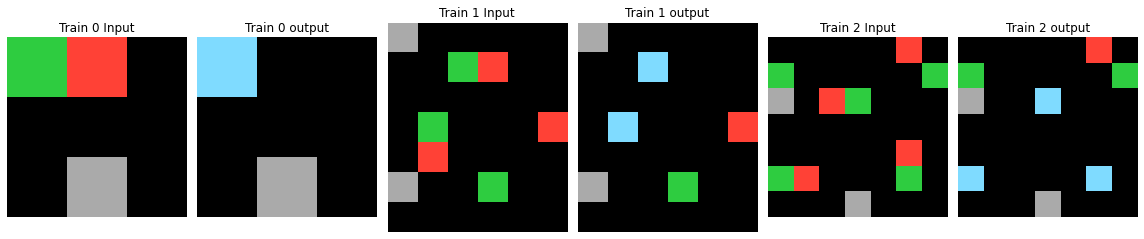

343


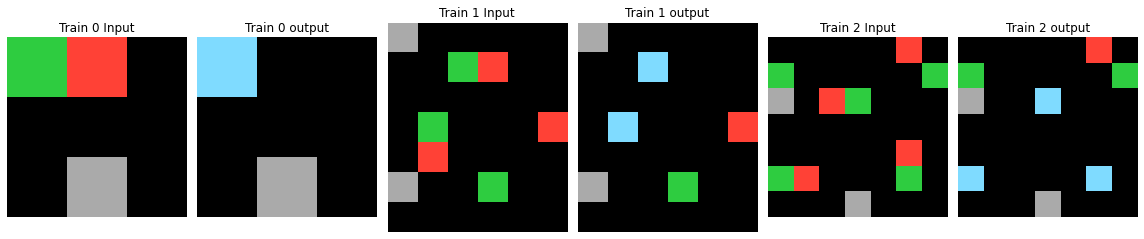

In [12]:
for n in screening_results['passed_some_traininputs']:
    print(n)
    plot_task(tt[n])
    print('=======')

In [ ]:
to_get_now = [48, 54, 72, 94, 96, 97, 119, 124, 186, 250, 251, 291, 292, 293, 316, 328, 337, 372]
more_prior_knowledge = [47, 66, 82, 105, 115, 129, 141, 142, 151, 136, 171, 193, 228, 248, 270, 310, 325, 354, 392]

len(to_get_now), len(more_prior_knowledge)

In [ ]:
knowns = load_serialized('assets/solved_indices_for_the_day.pkl')

In [ ]:
to_hook_up = [1, 345, 97, 119, 186, 250, 293, 337]
to_figure_out = [345, 48, 66, 105, 129, 151, 217, 290]

In [ ]:
# new
for n in current_attention:
    this_task = previous_analysis[n]
    print(n)
    plot_task(tt[n])
    print('pr_kn_apply_scenarios: ', this_task.pr_kn_apply_scenarios)
    print('=========')

In [ ]:
for n in [99, 128, 338] + [266, 388] + to_get_now:
    this_task = previous_analysis[n]
    print(n)
    plot_task(tt[n])
    print('pr_kn_apply_scenarios: ', this_task.pr_kn_apply_scenarios)
    print('=========')

In [ ]:
# 55, 202, 297: needs revisiting tokenization, objectivication schemes

In [ ]:
more_prior_knowledge = [47, 66, 82, 105, 115, 129, 141, 142, 151, 136, 171, 193, 228, 248,
                       270, 310, 325, 354, 392]
# 129, 290, 343, 345: more neighbor based featurization
# 47: is_two_red_objects_connected_by_blue_path

# output is vertical sorted based on frequency
# 66: output left most third versus center of rightmost third
# 134, 325: output is top right/left 1/nth corner

# 115, 171, 310: output is 180 flip vertical-double
# 136, 248: output is 180 flip horizontal double
# 82, 105, 141, 151, 193: output is a 90 flip 4-multiple

# 142: find a similar object to the object in the grey corner, turn it into grey

# 228: spare most frequent and grey everything else

# 270: output the object with the most blue cells
# 354: color encompassing more blue cells


In [ ]:
dimension_solution_attention = []
for n in range(400):
    this_task = previous_analysis[n]
    if this_task.is_complete_objective and this_task.dimension_status != 'deduced' and this_task.solved != 'solved':
        dimension_solution_attention.append(n)

In [ ]:
len(dimension_solution_attention)

In [ ]:
for n in dimension_solution_attention:
    this_task = previous_analysis[n]
    print(n)
    plot_task(tt[n])
    print('global_objective: ', sorted(this_task.global_objective))
    print('=========')

In [ ]:
to_solve_now = [48]
to_get_dim_now = [21, 28, 30, 38, 56, 78, 108, 120, 176, 187, 206, 215, 289, 299, 309, 324, 333, 350, 375, 395]

# 21, 152, 252: coallesce/fir objects into solution
# 28: output bound by a box
# 30, 56, 383: output multiples (one or more) of the only object in a vertical or horizontal or diagonal or offdiagonal
# 35, 206: output the unique/outsider object
# 78: output the most freeequent object
# 299: output the biggest object
# 324: output and imension is related to the number of objects
# 87: output the object and extend till anchors
# 38, 187: output the top left quadrant of the object, top half
# 108: find the object and output 90 flip 4-times and change its color
# 110, 120: output an object neighbor to an anchor with or without including/modifying the anchor
# 133: output the object, remove noise, change the object color to the noise
# 176, 217, 289: output everything other than bg
# 215, 395: output the box with most red cells
# 241, 350, 399: output is a reflection over a symmetry line on a black block
# 309: output the bounding box and what's inside
# 333: output is coded with the only nonbg
# 375: mutiple vertical

In [ ]:
# tokenized_graph, in_, x_situation, y_situation, sorted_frequency_graph, edge_situation, neighbor_situation
#         0         1       2            3              4                     5                    6                

In [ ]:
# fix test_token_to_colors 44, 52, 261, 265! this is only unexplaied 1% of objectification failure.
for case in [44, 52, 261, 265]:
    plot_task(tt[case], True)
    print('=====')